In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import folium

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src.data_preprocessing import prepare_crime_data
from src.feature_engineering import engineer_features

In [3]:
data_path = project_root / "data" / "raw" / "crime_dataset_india.csv"

df = prepare_crime_data(data_path)
df = engineer_features(df)

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (6458, 25)


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,...,Month,MonthName,Day,DayOfWeek,Hour,IsWeekend,IsNightCrime,VictimAgeGroup,IsCaseClosed,CaseResolutionDays
5,6,2020-01-02 03:00:00,2020-01-01 05:00:00,2020-01-01 17:09:00,Delhi,442,ASSAULT,16,M,Firearm,...,1,January,1,Wednesday,5,False,True,Child,True,88.0
10,11,2020-01-02 13:00:00,2020-01-01 10:00:00,2020-01-01 19:42:00,Delhi,260,FRAUD,71,M,Explosives,...,1,January,1,Wednesday,10,False,False,Senior,True,30.0
16,17,2020-01-03 07:00:00,2020-01-01 16:00:00,2020-01-02 02:57:00,Ghaziabad,509,DRUG OFFENSE,61,M,Poison,...,1,January,1,Wednesday,16,False,False,Senior,False,NaN
32,33,2020-01-03 04:00:00,2020-01-02 08:00:00,2020-01-03 03:01:00,Delhi,319,ILLEGAL POSSESSION,73,F,Knife,...,1,January,2,Thursday,8,False,False,Senior,False,NaN
42,43,2020-01-03 03:00:00,2020-01-02 18:00:00,2020-01-03 09:30:00,Delhi,172,FIREARM OFFENSE,40,M,Poison,...,1,January,2,Thursday,18,False,False,Adult,True,74.0


# City-wise Crime Intelligence

In [4]:
city_crime_summary = (
    df.groupby("City")
      .agg(
          TotalCrimes=("Crime Description", "count"),
          ViolentCrimes=("Crime Domain", lambda x: (x == "Violent Crime").sum()),
          NightCrimes=("IsNightCrime", "sum"),
          ClosedCases=("IsCaseClosed", "sum"),
          AveragePoliceDeployed=("Police Deployed", "mean")
      )
      .reset_index()
)

city_crime_summary["CaseClosureRate"] = (
    city_crime_summary["ClosedCases"]
    / city_crime_summary["TotalCrimes"]
    * 100
)

city_crime_summary["NightCrimeRate"] = (
    city_crime_summary["NightCrimes"]
    / city_crime_summary["TotalCrimes"]
    * 100
)

city_crime_summary = city_crime_summary.sort_values(
    by="TotalCrimes",
    ascending=False
).reset_index(drop=True)

city_crime_summary

,City,TotalCrimes,ViolentCrimes,NightCrimes,ClosedCases,AveragePoliceDeployed,CaseClosureRate,NightCrimeRate
0,Delhi,5400,1559,2267,2646,9.947963,49.000000,41.981481
1,Ghaziabad,704,206,285,340,10.176136,48.295455,40.482955
2,Faridabad,354,116,136,187,9.853107,52.824859,38.418079


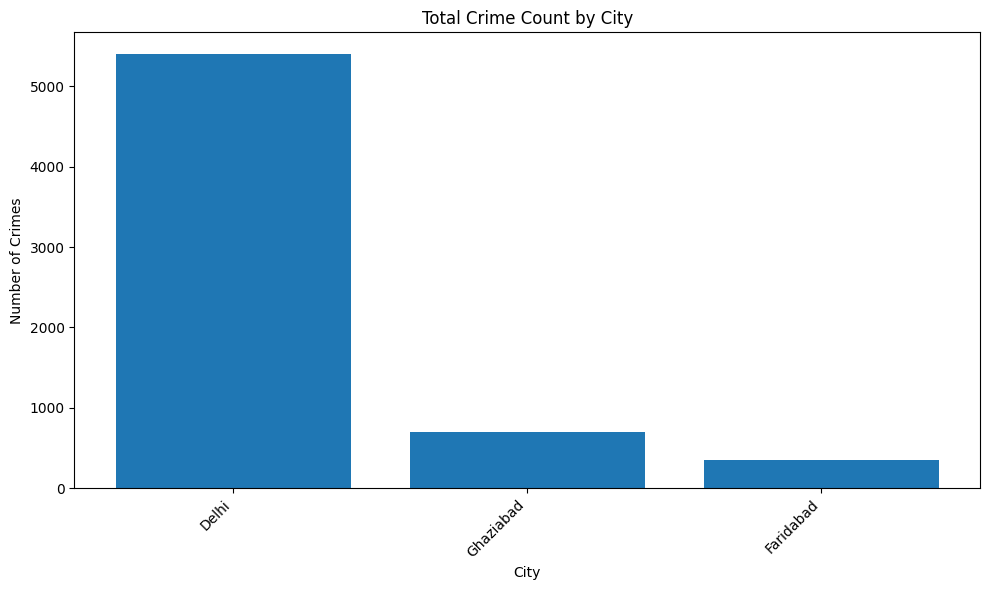

In [19]:


plt.figure(figsize=(10, 6))

plt.bar(
    city_crime_summary["City"],
    city_crime_summary["TotalCrimes"]
)

plt.title("Total Crime Count by City")
plt.xlabel("City")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
print("Top 3 Cities by Crime Count:\n")

display(
    city_crime_summary[
        [
            "City",
            "TotalCrimes",
            "ViolentCrimes",
            "NightCrimeRate",
            "CaseClosureRate"
        ]
    ].head(3)
)

Top 3 Cities by Crime Count:



,City,TotalCrimes,ViolentCrimes,NightCrimeRate,CaseClosureRate
0,Delhi,5400,1559,41.981481,49.000000
1,Ghaziabad,704,206,40.482955,48.295455
2,Faridabad,354,116,38.418079,52.824859


# Time-Based Crime Intelligence

In [7]:
hourly_crime = (
    df.groupby("Hour")
      .size()
      .reset_index(name="CrimeCount")
)

hourly_crime

,Hour,CrimeCount
0,0,267
1,1,305
2,2,265
3,3,260
4,4,265
5,5,273
6,6,271
7,7,268
8,8,265
9,9,238


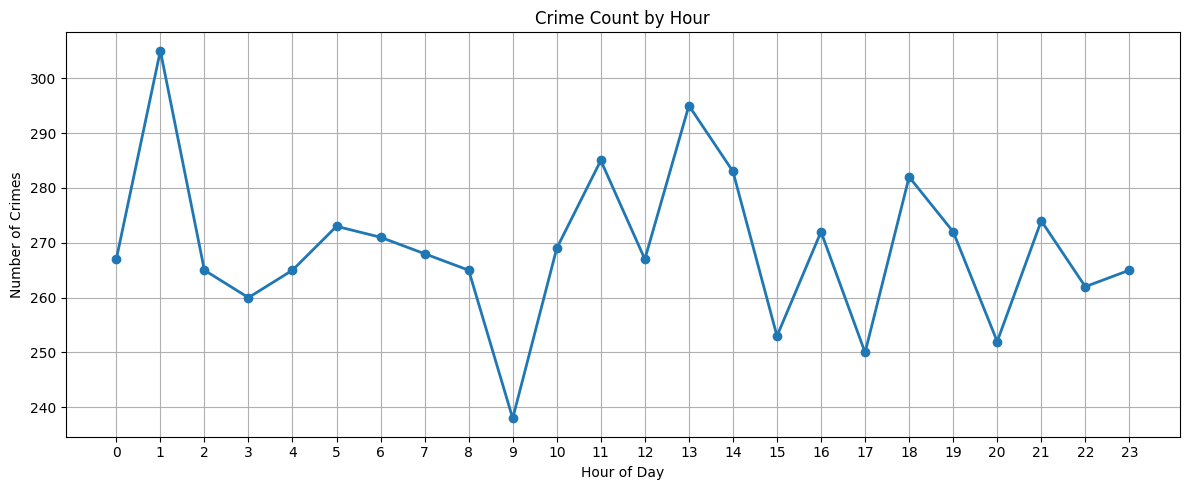

In [20]:


plt.figure(figsize=(12,5))

plt.plot(
    hourly_crime["Hour"],
    hourly_crime["CrimeCount"],
    marker="o",
    linewidth=2
)

plt.title("Crime Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
day_crime = (
    df.groupby("DayOfWeek")
      .size()
      .reset_index(name="CrimeCount")
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_crime["DayOfWeek"] = pd.Categorical(
    day_crime["DayOfWeek"],
    categories=day_order,
    ordered=True
)

day_crime = day_crime.sort_values("DayOfWeek")

day_crime

,DayOfWeek,CrimeCount
1,Monday,902
5,Tuesday,939
6,Wednesday,970
4,Thursday,939
0,Friday,940
2,Saturday,918
3,Sunday,850


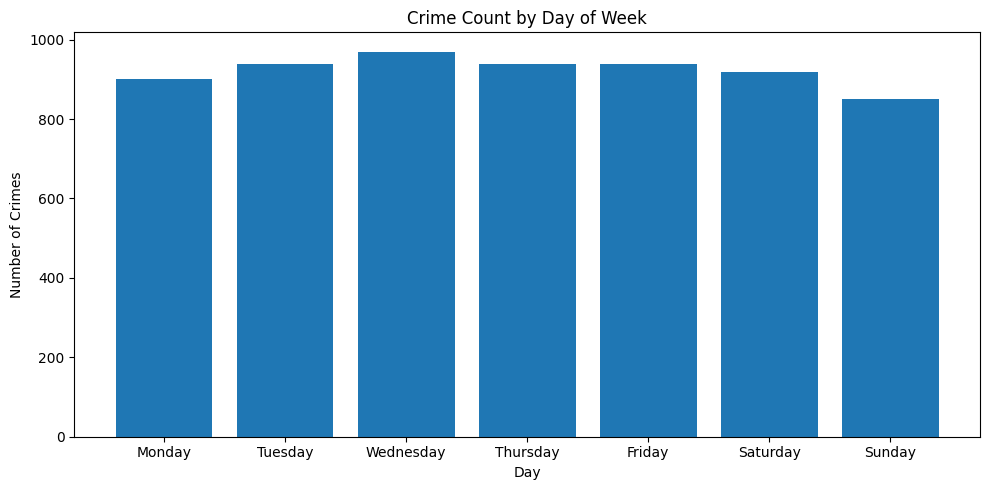

In [12]:
plt.figure(figsize=(10,5))

plt.bar(
    day_crime["DayOfWeek"],
    day_crime["CrimeCount"]
)

plt.title("Crime Count by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")

plt.tight_layout()
plt.show()

In [21]:


city_risk = city_crime_summary[
    ["City", "TotalCrimes"]
].copy()

city_risk["LogCrimeCount"] = np.log1p(
    city_risk["TotalCrimes"]
)

min_city_log = city_risk["LogCrimeCount"].min()
max_city_log = city_risk["LogCrimeCount"].max()

city_risk["CityRiskScore"] = (
    (city_risk["LogCrimeCount"] - min_city_log)
    / (max_city_log - min_city_log)
    * 100
)

city_risk = city_risk.drop(columns=["LogCrimeCount"])

city_risk

,City,TotalCrimes,CityRiskScore
0,Delhi,5400,100.000000
1,Ghaziabad,704,25.202945
2,Faridabad,354,0.000000


In [15]:
# Normalize hourly crime counts to a 0–100 scale

hour_risk = hourly_crime.copy()

min_hour_crime = hour_risk["CrimeCount"].min()
max_hour_crime = hour_risk["CrimeCount"].max()

hour_risk["HourRiskScore"] = (
    (hour_risk["CrimeCount"] - min_hour_crime)
    / (max_hour_crime - min_hour_crime)
    * 100
)

hour_risk

,Hour,CrimeCount,HourRiskScore
0,0,267,43.283582
1,1,305,100.000000
2,2,265,40.298507
3,3,260,32.835821
4,4,265,40.298507
5,5,273,52.238806
6,6,271,49.253731
7,7,268,44.776119
8,8,265,40.298507
9,9,238,0.000000


In [16]:
# Normalize day-wise crime counts to a 0–100 scale

day_risk = day_crime.copy()

min_day_crime = day_risk["CrimeCount"].min()
max_day_crime = day_risk["CrimeCount"].max()

day_risk["DayRiskScore"] = (
    (day_risk["CrimeCount"] - min_day_crime)
    / (max_day_crime - min_day_crime)
    * 100
)

day_risk

,DayOfWeek,CrimeCount,DayRiskScore
1,Monday,902,43.333333
5,Tuesday,939,74.166667
6,Wednesday,970,100.000000
4,Thursday,939,74.166667
0,Friday,940,75.000000
2,Saturday,918,56.666667
3,Sunday,850,0.000000


In [22]:
city_score_lookup = city_risk.set_index(
    "City"
)["CityRiskScore"].to_dict()

hour_score_lookup = hour_risk.set_index(
    "Hour"
)["HourRiskScore"].to_dict()

day_score_lookup = day_risk.set_index(
    "DayOfWeek"
)["DayRiskScore"].to_dict()

print("City lookup:", city_score_lookup)
print("\nHour lookup created for", len(hour_score_lookup), "hours")
print("Day lookup:", day_score_lookup)

City lookup: {'Delhi': 100.0, 'Ghaziabad': 25.202944923180446, 'Faridabad': 0.0}

Hour lookup created for 24 hours
Day lookup: {'Monday': 43.333333333333336, 'Tuesday': 74.16666666666667, 'Wednesday': 100.0, 'Thursday': 74.16666666666667, 'Friday': 75.0, 'Saturday': 56.666666666666664, 'Sunday': 0.0}


In [23]:
def calculate_risk_score(
    city: str,
    day: str,
    hour: int
) -> dict:
    """
    Calculate a public-safety risk score using historical
    city, day and hourly crime patterns.
    """

    if city not in city_score_lookup:
        raise ValueError(f"Unknown city: {city}")

    if day not in day_score_lookup:
        raise ValueError(f"Unknown day: {day}")

    if hour not in range(24):
        raise ValueError("Hour must be between 0 and 23.")

    city_score = city_score_lookup[city]
    hour_score = hour_score_lookup[hour]
    day_score = day_score_lookup[day]

    # Night period: 8 PM to 5:59 AM
    night_score = 100 if hour >= 20 or hour <= 5 else 0

    final_score = (
        city_score * 0.40
        + hour_score * 0.30
        + day_score * 0.20
        + night_score * 0.10
    )

    final_score = round(final_score, 2)

    if final_score >= 70:
        risk_level = "High"
    elif final_score >= 40:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    return {
        "City": city,
        "Day": day,
        "Hour": hour,
        "CityRiskComponent": round(city_score, 2),
        "HourRiskComponent": round(hour_score, 2),
        "DayRiskComponent": round(day_score, 2),
        "NightRiskComponent": night_score,
        "RiskScore": final_score,
        "RiskLevel": risk_level
    }

In [24]:
delhi_result = calculate_risk_score(
    city="Delhi",
    day="Wednesday",
    hour=1
)

ghaziabad_result = calculate_risk_score(
    city="Ghaziabad",
    day="Friday",
    hour=22
)

faridabad_result = calculate_risk_score(
    city="Faridabad",
    day="Sunday",
    hour=9
)

print("Delhi Example:")
print(delhi_result)

print("\nGhaziabad Example:")
print(ghaziabad_result)

print("\nFaridabad Example:")
print(faridabad_result)

Delhi Example:
{'City': 'Delhi', 'Day': 'Wednesday', 'Hour': 1, 'CityRiskComponent': 100.0, 'HourRiskComponent': 100.0, 'DayRiskComponent': 100.0, 'NightRiskComponent': 100, 'RiskScore': 100.0, 'RiskLevel': 'High'}

Ghaziabad Example:
{'City': 'Ghaziabad', 'Day': 'Friday', 'Hour': 22, 'CityRiskComponent': 25.2, 'HourRiskComponent': 35.82, 'DayRiskComponent': 75.0, 'NightRiskComponent': 100, 'RiskScore': 45.83, 'RiskLevel': 'Medium'}

Faridabad Example:
{'City': 'Faridabad', 'Day': 'Sunday', 'Hour': 9, 'CityRiskComponent': 0.0, 'HourRiskComponent': 0.0, 'DayRiskComponent': 0.0, 'NightRiskComponent': 0, 'RiskScore': 0.0, 'RiskLevel': 'Low'}


# Safety Recommendation Engine

In [25]:
def generate_safety_recommendations(
    risk_result: dict
) -> dict:
    """
    Generate public-safety recommendations based on the
    calculated risk level, selected hour and city.
    """

    risk_level = risk_result["RiskLevel"]
    risk_score = risk_result["RiskScore"]
    city = risk_result["City"]
    day = risk_result["Day"]
    hour = risk_result["Hour"]

    recommendations = []

    # Recommendations based on risk level
    if risk_level == "High":
        recommendations.extend([
            "Avoid travelling alone whenever possible.",
            "Prefer busy, well-lit and frequently used routes.",
            "Share your live location with a trusted person.",
            "Use verified public transport or trusted cab services.",
            "Keep emergency contact numbers easily accessible."
        ])

    elif risk_level == "Medium":
        recommendations.extend([
            "Remain alert and avoid isolated streets.",
            "Prefer well-lit and populated routes.",
            "Inform someone about your expected arrival time.",
            "Keep your phone charged before travelling."
        ])

    else:
        recommendations.extend([
            "Follow normal personal-safety precautions.",
            "Stay aware of your surroundings.",
            "Keep important contact numbers available."
        ])

    # Extra night-time recommendations
    if hour >= 20 or hour <= 5:
        recommendations.extend([
            "Avoid poorly lit areas during night hours.",
            "Do not display valuables openly.",
            "Consider travelling with a companion."
        ])

    # Remove duplicate recommendations
    recommendations = list(dict.fromkeys(recommendations))

    return {
        "City": city,
        "Day": day,
        "Hour": hour,
        "RiskScore": risk_score,
        "RiskLevel": risk_level,
        "Recommendations": recommendations
    }

In [26]:
delhi_safety = generate_safety_recommendations(
    delhi_result
)

ghaziabad_safety = generate_safety_recommendations(
    ghaziabad_result
)

faridabad_safety = generate_safety_recommendations(
    faridabad_result
)

print("Delhi Safety Report:\n")

print(
    f"Risk Score: {delhi_safety['RiskScore']} | "
    f"Risk Level: {delhi_safety['RiskLevel']}"
)

for number, recommendation in enumerate(
    delhi_safety["Recommendations"],
    start=1
):
    print(f"{number}. {recommendation}")

Delhi Safety Report:

Risk Score: 100.0 | Risk Level: High
1. Avoid travelling alone whenever possible.
2. Prefer busy, well-lit and frequently used routes.
3. Share your live location with a trusted person.
4. Use verified public transport or trusted cab services.
5. Keep emergency contact numbers easily accessible.
6. Avoid poorly lit areas during night hours.
7. Do not display valuables openly.
8. Consider travelling with a companion.


In [27]:
print("\nGhaziabad Safety Report:\n")

print(
    f"Risk Score: {ghaziabad_safety['RiskScore']} | "
    f"Risk Level: {ghaziabad_safety['RiskLevel']}"
)

for number, recommendation in enumerate(
    ghaziabad_safety["Recommendations"],
    start=1
):
    print(f"{number}. {recommendation}")


print("\nFaridabad Safety Report:\n")

print(
    f"Risk Score: {faridabad_safety['RiskScore']} | "
    f"Risk Level: {faridabad_safety['RiskLevel']}"
)

for number, recommendation in enumerate(
    faridabad_safety["Recommendations"],
    start=1
):
    print(f"{number}. {recommendation}")


Ghaziabad Safety Report:

Risk Score: 45.83 | Risk Level: Medium
1. Remain alert and avoid isolated streets.
2. Prefer well-lit and populated routes.
3. Inform someone about your expected arrival time.
4. Keep your phone charged before travelling.
5. Avoid poorly lit areas during night hours.
6. Do not display valuables openly.
7. Consider travelling with a companion.

Faridabad Safety Report:

Risk Score: 0.0 | Risk Level: Low
1. Follow normal personal-safety precautions.
2. Stay aware of your surroundings.
3. Keep important contact numbers available.
